<a href="https://colab.research.google.com/github/Monish-ch/Deep-Learning/blob/main/Experiment-1.ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

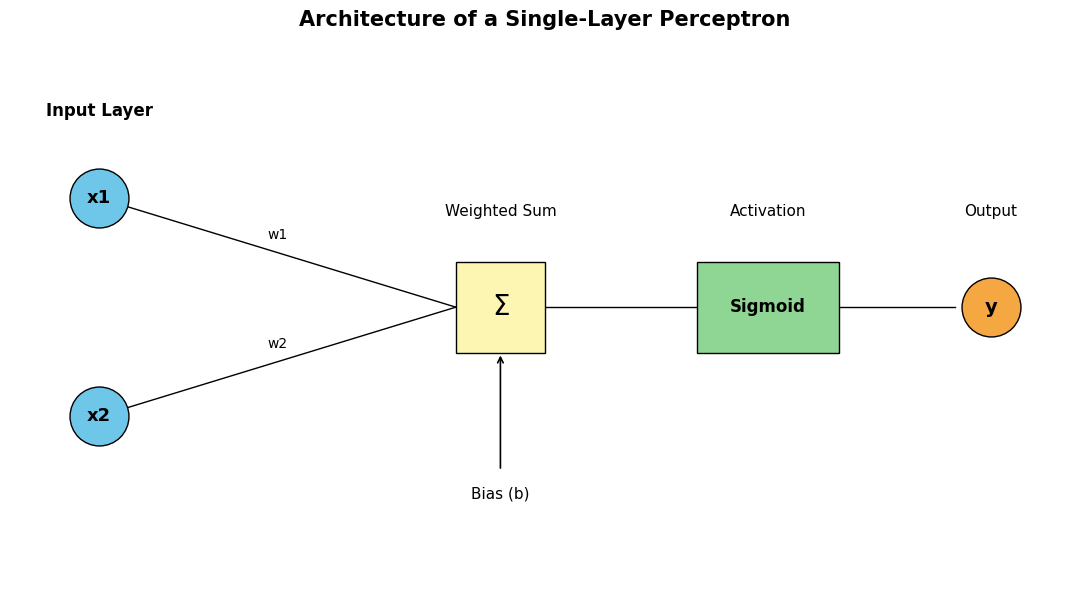

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis('off')

# ---------- Input neurons ----------
input_coords = [(1, 4.2), (1, 1.8)]
input_labels = ['x1', 'x2']

for (px, py), label in zip(input_coords, input_labels):
    ax.scatter(px, py, s=1800, color='#6EC6E8', edgecolors='black', zorder=3)
    ax.text(px, py, label, ha='center', va='center', fontsize=13, fontweight='bold', zorder=4)

# ---------- Weighted sum box ----------
sum_box_center = (5.5, 3)
ax.add_patch(plt.Rectangle((5.0, 2.5), 1.0, 1.0, facecolor='#FDF6B2', edgecolor='black', zorder=2))
ax.text(5.5, 3, r'$\Sigma$', ha='center', va='center', fontsize=20, zorder=4)

# ---------- Activation box ----------
ax.add_patch(plt.Rectangle((7.7, 2.5), 1.6, 1.0, facecolor='#8FD694', edgecolor='black', zorder=2))
ax.text(8.5, 3, 'Sigmoid', ha='center', va='center', fontsize=12, fontweight='bold', zorder=4)

# ---------- Output neuron ----------
ax.scatter(11, 3, s=1800, color='#F5A742', edgecolors='black', zorder=3)
ax.text(11, 3, 'y', ha='center', va='center', fontsize=14, fontweight='bold', zorder=4)

# ---------- Connections: inputs -> weighted sum ----------
for (px, py), wlabel in zip(input_coords, ['w1', 'w2']):
    ax.plot([px, 5.0], [py, 3], color='black', linewidth=1, zorder=1)
    mid_x, mid_y = (px + 5.0) / 2, (py + 3) / 2
    ax.text(mid_x, mid_y + 0.15, wlabel, fontsize=10, ha='center')

# ---------- Connection: weighted sum -> activation ----------
ax.plot([6.0, 7.7], [3, 3], color='black', linewidth=1, zorder=1)

# ---------- Connection: activation -> output ----------
ax.plot([9.3, 10.6], [3, 3], color='black', linewidth=1, zorder=1)

# ---------- Bias arrow ----------
ax.annotate('', xy=(5.5, 2.5), xytext=(5.5, 1.2),
            arrowprops=dict(arrowstyle='->', color='black', linewidth=1.2))
ax.text(5.5, 0.9, 'Bias (b)', ha='center', fontsize=11)

# ---------- Section labels ----------
ax.text(1, 5.1, 'Input Layer', ha='center', fontsize=12, fontweight='bold')
ax.text(5.5, 4.0, 'Weighted Sum', ha='center', fontsize=11)
ax.text(8.5, 4.0, 'Activation', ha='center', fontsize=11)
ax.text(11, 4.0, 'Output', ha='center', fontsize=11)

plt.title('Architecture of a Single-Layer Perceptron', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

and_table=pd.DataFrame({
    "Input x1":[0,0,1,1],
    "Input x2":[0,1,0,1],
    "AND Output":[0,0,0,1]
})

print(and_table)

   Input x1  Input x2  AND Output
0         0         0           0
1         0         1           0
2         1         0           0
3         1         1           1


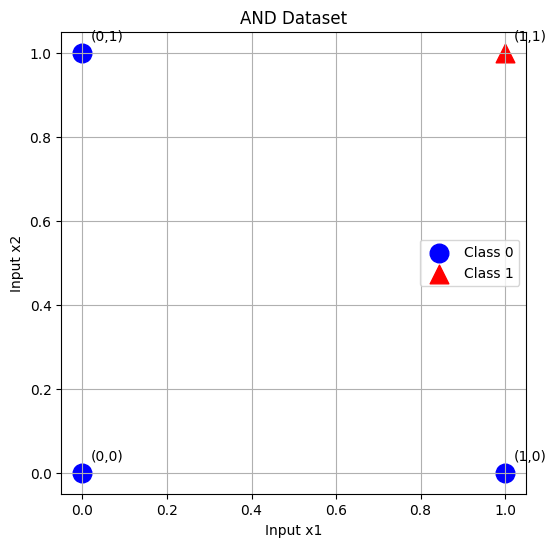

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])

plt.figure(figsize=(6,6))

plt.scatter(X[y==0][:,0],X[y==0][:,1],
            color="blue",s=180,label="Class 0")

plt.scatter(X[y==1][:,0],X[y==1][:,1],
            color="red",marker="^",s=180,label="Class 1")

labels=["(0,0)","(0,1)","(1,0)","(1,1)"]

for point,label in zip(X,labels):
    plt.text(point[0]+0.02,point[1]+0.03,label)

plt.xlabel("Input x1")
plt.ylabel("Input x2")
plt.title("AND Dataset")
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
import numpy as np
import tensorflow as tf

# AND Dataset
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
], dtype=np.float32)

y = np.array([
    [0],
    [0],
    [0],
    [1]
], dtype=np.float32)

# Single Layer Perceptron
model = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X,
    y,
    epochs=3000,
    verbose=0
)

# Evaluate
loss, accuracy = model.evaluate(X, y, verbose=0)

print(f"\nLoss: {loss:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")

# Predictions
predictions = model.predict(X, verbose=0)

print("\nPredictions")
print("-"*55)
print("Input\tActual\tProbability\tPredicted")

for i in range(len(X)):
    predicted = 1 if predictions[i][0] >= 0.5 else 0
    print(f"{X[i]}\t{int(y[i][0])}\t{predictions[i][0]:.4f}\t\t{predicted}")


Loss: 0.0567
Accuracy: 100.00%

Predictions
-------------------------------------------------------
Input	Actual	Probability	Predicted
[0. 0.]	0	0.0005		0
[0. 1.]	0	0.0640		0
[1. 0.]	0	0.0640		0
[1. 1.]	1	0.9102		1


In [ ]:
import pandas as pd

or_table = pd.DataFrame({
    "Input x1": [0, 0, 1, 1],
    "Input x2": [0, 1, 0, 1],
    "OR Output": [0, 1, 1, 1]
})

print(or_table)

   Input x1  Input x2  OR Output
0         0         0          0
1         0         1          1
2         1         0          1
3         1         1          1


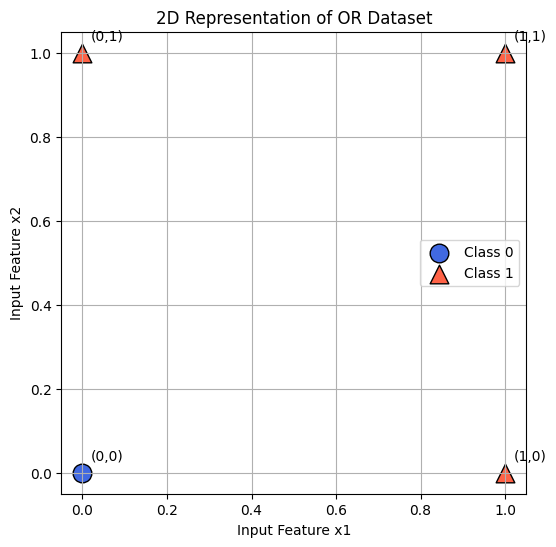

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,1,1,1])

plt.figure(figsize=(6,6))

# Class 0
plt.scatter(
    X[y==0][:,0],
    X[y==0][:,1],
    color="royalblue",
    s=180,
    edgecolor="black",
    label="Class 0"
)

# Class 1
plt.scatter(
    X[y==1][:,0],
    X[y==1][:,1],
    color="tomato",
    marker="^",
    s=180,
    edgecolor="black",
    label="Class 1"
)

labels=["(0,0)","(0,1)","(1,0)","(1,1)"]

for point,label in zip(X,labels):
    plt.text(point[0]+0.02,point[1]+0.03,label)

plt.xlabel("Input Feature x1")
plt.ylabel("Input Feature x2")
plt.title("2D Representation of OR Dataset")
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
import numpy as np
import tensorflow as tf

# OR Dataset
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
], dtype=np.float32)

y = np.array([
    [0],
    [1],
    [1],
    [1]
], dtype=np.float32)

# Single Layer Perceptron
model = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X,
    y,
    epochs=3000,
    verbose=0
)

# Evaluate
loss, accuracy = model.evaluate(X, y, verbose=0)

print(f"\nLoss: {loss:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")

# Predictions
predictions = model.predict(X, verbose=0)

print("\nPredictions")
print("-"*55)
print("Input\tActual\tProbability\tPredicted")

for i in range(len(X)):
    predicted = 1 if predictions[i][0] >= 0.5 else 0
    print(f"{X[i]}\t{int(y[i][0])}\t{predictions[i][0]:.4f}\t\t{predicted}")


Loss: 0.0312
Accuracy: 100.00%

Predictions
-------------------------------------------------------
Input	Actual	Probability	Predicted
[0. 0.]	0	0.0678		0
[0. 1.]	1	0.9732		1
[1. 0.]	1	0.9728		1
[1. 1.]	1	0.9999		1


In [ ]:
import pandas as pd

xor_table = pd.DataFrame({
    "Input x1": [0, 0, 1, 1],
    "Input x2": [0, 1, 0, 1],
    "XOR Output": [0, 1, 1, 0]
})

print(xor_table)

   Input x1  Input x2  XOR Output
0         0         0           0
1         0         1           1
2         1         0           1
3         1         1           0


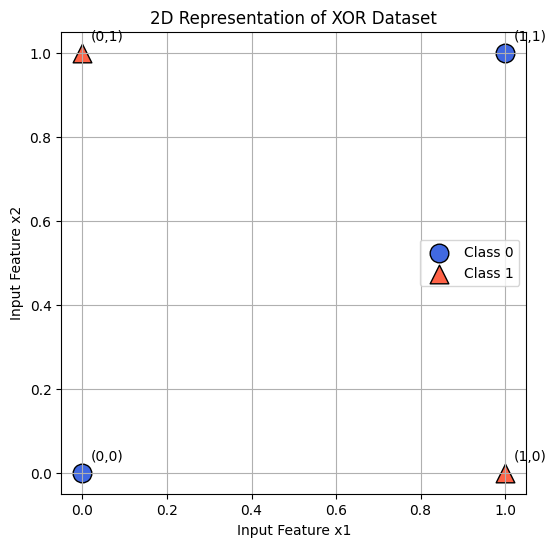

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,1,1,0])

plt.figure(figsize=(6,6))

# Class 0
plt.scatter(
    X[y==0][:,0],
    X[y==0][:,1],
    color="royalblue",
    s=180,
    edgecolor="black",
    label="Class 0"
)

# Class 1
plt.scatter(
    X[y==1][:,0],
    X[y==1][:,1],
    color="tomato",
    marker="^",
    s=180,
    edgecolor="black",
    label="Class 1"
)

labels=["(0,0)","(0,1)","(1,0)","(1,1)"]

for point,label in zip(X,labels):
    plt.text(point[0]+0.02,point[1]+0.03,label)

plt.xlabel("Input Feature x1")
plt.ylabel("Input Feature x2")
plt.title("2D Representation of XOR Dataset")
plt.grid(True)
plt.legend()

plt.show()

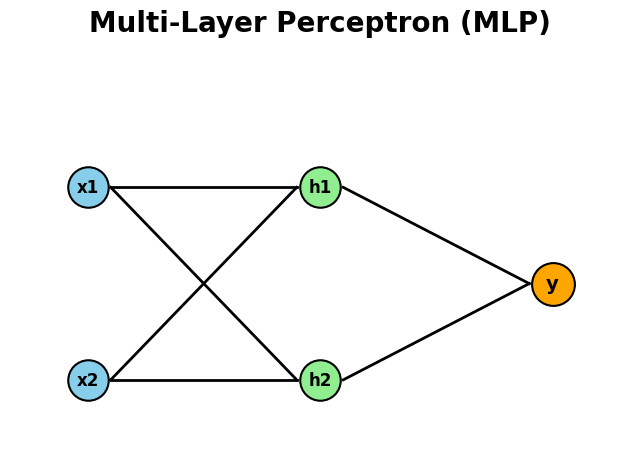

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

ax.set_xlim(0,8)
ax.set_ylim(0,6)
ax.axis('off')

# ---------------- Input Layer ----------------
inputs = [(1,4), (1,1)]

for i, (x, y) in enumerate(inputs):
    ax.scatter(x, y,
               s=850,
               color='skyblue',
               edgecolors='black',
               linewidth=1.5)
    ax.text(x, y, f'x{i+1}',
            ha='center',
            va='center',
            fontsize=12,
            fontweight='bold')

# ---------------- Hidden Layer ----------------
hidden = [(4,4), (4,1)]

for i, (x, y) in enumerate(hidden):
    ax.scatter(x, y,
               s=850,
               color='lightgreen',
               edgecolors='black',
               linewidth=1.5)
    ax.text(x, y, f'h{i+1}',
            ha='center',
            va='center',
            fontsize=12,
            fontweight='bold')

# ---------------- Output Layer ----------------
output = (7,2.5)

ax.scatter(output[0], output[1],
           s=950,
           color='orange',
           edgecolors='black',
           linewidth=1.5)

ax.text(output[0], output[1], 'y',
        ha='center',
        va='center',
        fontsize=14,
        fontweight='bold')

# ---------------- Connections ----------------
# x1 → h1
ax.plot([1.3,3.7],[4,4],color='black',linewidth=2)

# x1 → h2
ax.plot([1.3,3.7],[4,1],color='black',linewidth=2)

# x2 → h1
ax.plot([1.3,3.7],[1,4],color='black',linewidth=2)

# x2 → h2
ax.plot([1.3,3.7],[1,1],color='black',linewidth=2)

# Hidden → Output
ax.plot([4.3,6.7],[4,2.5],color='black',linewidth=2)
ax.plot([4.3,6.7],[1,2.5],color='black',linewidth=2)

# ---------------- Title ----------------
plt.title("Multi-Layer Perceptron (MLP)",
          fontsize=20,
          fontweight='bold',
          pad=20)

plt.show()

In [ ]:
import numpy as np
import tensorflow as tf

# Clear previous session
tf.keras.backend.clear_session()

# Random seed
np.random.seed(42)
tf.random.set_seed(42)

# XOR Dataset
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
], dtype=np.float32)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=np.float32)

# Build MLP Model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),
    tf.keras.layers.Dense(
        4,
        activation='sigmoid'
    ),
    tf.keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])

# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.005
    ),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    X,
    y,
    epochs=1000,
    verbose=0
)

# Evaluate Model
loss, accuracy = model.evaluate(
    X,
    y,
    verbose=0
)

print("Final Model Performance")
print("-"*40)
print(f"Loss     : {loss:.4f}")
print(f"Accuracy : {accuracy*100:.2f}%")

# Predictions
pred = model.predict(X, verbose=0)

print("\nNetwork Predictions")
print("-"*70)
print("Sample\tInput\tTarget\tProbability\tPrediction")

for i in range(len(X)):
    p = pred[i][0]
    c = 1 if p >= 0.5 else 0

    print(f"{i+1}\t{X[i]}\t{int(y[i][0])}\t{p:.4f}\t\t{c}")

Final Model Performance
----------------------------------------
Loss     : 0.0547
Accuracy : 100.00%



Network Predictions
----------------------------------------------------------------------
Sample	Input	Target	Probability	Prediction
1	[0. 0.]	0	0.0150		0
2	[0. 1.]	1	0.9805		1
3	[1. 0.]	1	0.9157		1
4	[1. 1.]	0	0.0917		0


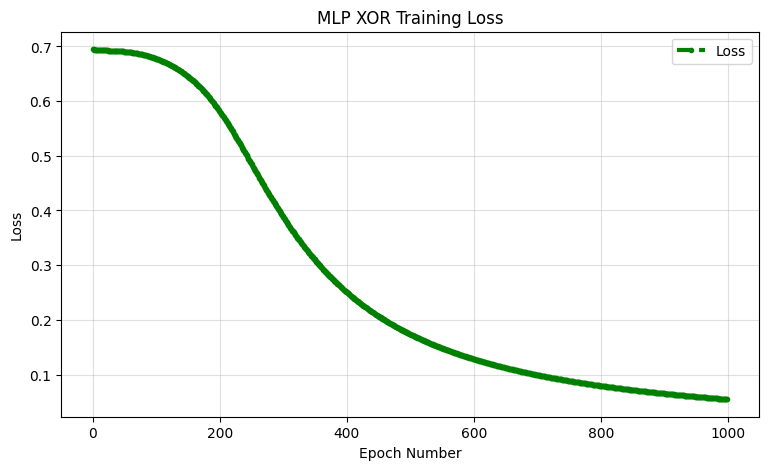

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.plot(
    history.history['loss'],
    color='green',
    linewidth=3,
    linestyle='--',
    marker='o',
    markersize=3,
    label='Loss'
)

plt.title("MLP XOR Training Loss")
plt.xlabel("Epoch Number")
plt.ylabel("Loss")
plt.grid(alpha=0.4)
plt.legend()
plt.show()

In [ ]:
# Final Predictions

pred = model.predict(X, verbose=0)

print("Final Prediction Results")
print("-"*75)
print("Sample\tInput\tTarget\tProbability\tPredicted Class")

for i in range(len(X)):

    probability = pred[i][0]

    predicted_class = 1 if probability >= 0.5 else 0

    print(f"{i+1}\t{X[i]}\t{int(y[i][0])}\t{probability:.4f}\t\t{predicted_class}")

# Model Evaluation

loss, accuracy = model.evaluate(X, y, verbose=0)

print("\nModel Evaluation")
print("-"*30)
print(f"Final Loss     : {loss:.4f}")
print(f"Final Accuracy : {accuracy*100:.2f}%")

Final Prediction Results
---------------------------------------------------------------------------
Sample	Input	Target	Probability	Predicted Class
1	[0. 0.]	0	0.0150		0
2	[0. 1.]	1	0.9805		1
3	[1. 0.]	1	0.9157		1
4	[1. 1.]	0	0.0917		0

Model Evaluation
------------------------------
Final Loss     : 0.0547
Final Accuracy : 100.00%
